# Customer Churn Prediction
This notebook predicts customer churn using classification models.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## Load Data

In [2]:
df = pd.read_csv(r'c:\Users\aryan\OneDrive\Desktop\AI ML\ASSIGNMENT\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df.drop('customerID', axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Exploration

In [3]:
print(df.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


## Data Cleaning

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

imputer = SimpleImputer(strategy="median")
df["TotalCharges"] = imputer.fit_transform(df[["TotalCharges"]])

print(df.duplicated().sum())
df = df.drop_duplicates()

22


## Remove Outliers

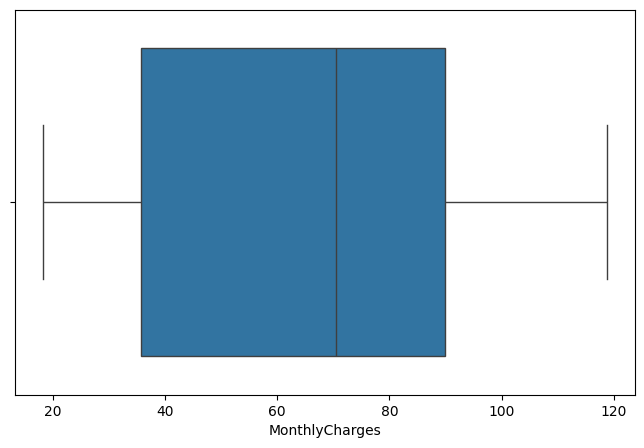

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["MonthlyCharges"])
plt.show()

q1 = df["MonthlyCharges"].quantile(0.25)
q3 = df["MonthlyCharges"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df = df[(df["MonthlyCharges"] >= lower) & (df["MonthlyCharges"] <= upper)]

## Data Visualization

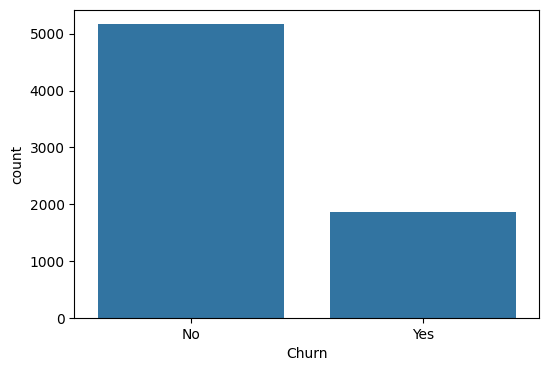

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.show()

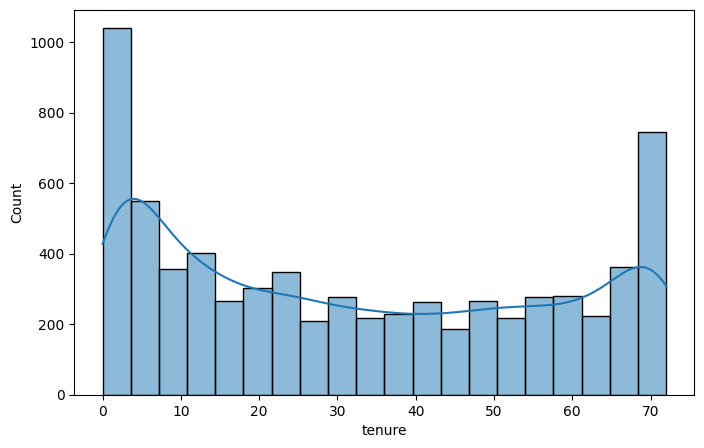

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["tenure"], bins=20, kde=True)
plt.show()

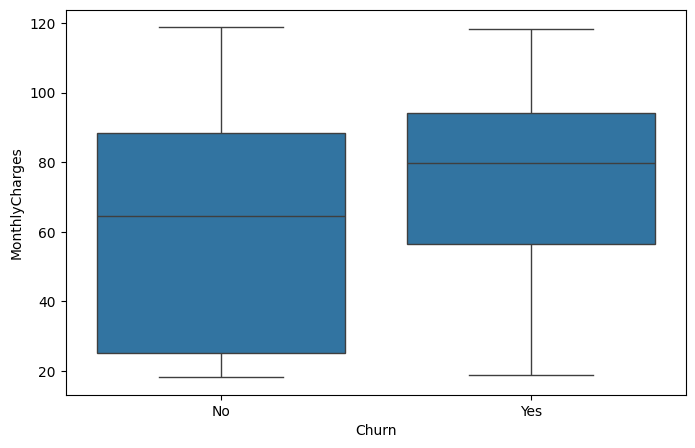

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

## Encode Categorical Features

In [10]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object" or pd.api.types.is_string_dtype(df[col]):
        df[col] = le.fit_transform(df[col])

## Prepare Features and Target

In [11]:
x = df.drop("Churn", axis=1)
y = df["Churn"]

## Scale Features

In [12]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

## Train-Test Split

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

In [14]:
log_model = LogisticRegression()
tree_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

log_model.fit(x_train, y_train)
tree_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Model Predictions

In [15]:
log_pred = log_model.predict(x_test)
tree_pred = tree_model.predict(x_test)
rf_pred = rf_model.predict(x_test)

## Model Evaluation

In [16]:
log_acc = accuracy_score(y_test, log_pred)
tree_acc = accuracy_score(y_test, tree_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", log_acc)
print("Decision Tree Accuracy:", tree_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.7957295373665481
Decision Tree Accuracy: 0.7366548042704626
Random Forest Accuracy: 0.7843416370106762


## Classification Reports

In [17]:
print("Logistic Regression:")
print(classification_report(y_test, log_pred))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1053
           1       0.61      0.53      0.56       352

    accuracy                           0.80      1405
   macro avg       0.73      0.71      0.71      1405
weighted avg       0.79      0.80      0.79      1405



In [18]:
print("Decision Tree:")
print(classification_report(y_test, tree_pred))

Decision Tree:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1053
           1       0.48      0.51      0.49       352

    accuracy                           0.74      1405
   macro avg       0.65      0.66      0.66      1405
weighted avg       0.74      0.74      0.74      1405



In [19]:
print("Random Forest:")
print(classification_report(y_test, rf_pred))

Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1053
           1       0.59      0.46      0.52       352

    accuracy                           0.78      1405
   macro avg       0.71      0.68      0.69      1405
weighted avg       0.77      0.78      0.77      1405



## Model Comparison

In [20]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
scores = [log_acc, tree_acc, rf_acc]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": scores
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.795730
1        Decision Tree  0.736655
2        Random Forest  0.784342


## Model Comparison Visualization

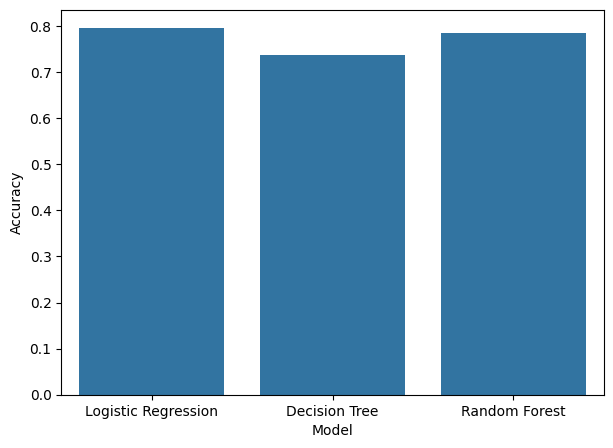

In [21]:
plt.figure(figsize=(7, 5))
sns.barplot(x="Model", y="Accuracy", data=comparison)
plt.show()